# MNIST Regularization (PyTorch)

Dieses Notebook zeigt verschiedene Regularisierungsmethoden auf einem einfachen MLP für MNIST – vollständig in PyTorch und mit expliziten Gewichts-Parametern.

Abgedeckte Kategorien:
- Weiche Regularisierung: L2, L1 (zusätzlicher Term)
- Early Stopping
- Regularisierung durch Dropout
- Label Smoothing

Voraussetzungen (lokal):
```bash
pip install torch torchvision matplotlib
```


In [33]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from tqdm import tqdm
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


In [34]:
# Daten laden (MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

val_size = 500
train_size = int(len(train_full)*0.1 - val_size)

indices = torch.randperm(len(train_full), generator=torch.Generator().manual_seed(42))[:(val_size+int(train_size))]
indices_test = torch.randperm(len(test_ds), generator=torch.Generator().manual_seed(42))[:val_size]

small_ds = Subset(train_full, indices)
small_test_ds = Subset(test_ds, indices_test)

train_ds, val_ds = random_split(small_ds, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(small_test_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

len(train_ds), len(val_ds), len(small_test_ds)


(5500, 500, 500)

In [35]:
# Einfaches MLP

class MLP(nn.Module):
    def __init__(self, hidden=64, dropout=0.0, use_bn=False):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, hidden)
        self.bn1 = nn.BatchNorm1d(hidden) if use_bn else None
        self.dropout = nn.Dropout(p=dropout) if dropout > 0 else None
        self.fc2 = nn.Linear(hidden, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        if self.bn1 is not None:
            x = self.bn1(x)
        x = F.relu(x)
        if self.dropout is not None:
            x = self.dropout(x)
        x = self.fc2(x)
        return x

In [36]:
def accuracy(logits, y):
    return (logits.argmax(1) == y).float().mean().item()

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, total_correct / total



In [37]:
model = MLP(hidden=64,
            dropout=0.0,
            use_bn= False).to(device)

# Hier können die Parameter für die Regularisierungen eingestellt werden

epochs = 10
label_smoothing = 0.0
lambda_l2 = 0.0
lambda_l1 = 1e-5
early_stopping = False
patience = 5

name = 'model_L1'

criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
optimizer = torch.optim.Adam(model.parameters(), lr= 1e-3)



In [38]:

best_val = float('inf')
best_state = None
wait = 0

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    n = 0
    print('Starting epoch ', epoch)
    for xb, yb in tqdm(train_loader):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        if lambda_l1 > 0:
            l1_reg = torch.tensor(0.)
            for param in model.parameters():
                l1_reg += torch.sum(torch.abs(param))
            loss = loss + lambda_l1 * l1_reg
        if lambda_l2 >0:
            l2_reg = torch.tensor(0.)
            for param in model.parameters():
                l2_reg += torch.norm(param)
            loss = loss + lambda_l2 * l2_reg
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        n += xb.size(0)

    train_loss = running_loss / n
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if 'use_early_stopping'==True:
        if val_loss < best_val - 1e-4:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print('Early stopping')
                break

if best_state is not None:
    model.load_state_dict(best_state)

test_loss, test_acc = evaluate(model, test_loader, criterion)

Starting epoch  1


  0%|          | 0/43 [00:00<?, ?it/s]c:\Users\johannes.schwab\AppData\Local\miniconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
100%|██████████| 43/43 [00:07<00:00,  5.86it/s]


Starting epoch  2


100%|██████████| 43/43 [00:07<00:00,  5.95it/s]


Starting epoch  3


...

100%|██████████| 43/43 [00:07<00:00,  5.87it/s]


Starting epoch  9


100%|██████████| 43/43 [00:07<00:00,  6.13it/s]


Starting epoch  10


100%|██████████| 43/43 [00:07<00:00,  5.84it/s]


In [39]:

print(f" | best val loss: {val_loss:.4f} | test acc: {test_acc:.4f}")


 | best val loss: 0.2806 | test acc: 0.9380


C:\Users\johannes.schwab\AppData\Local\Temp\ipykernel_27964\746122469.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


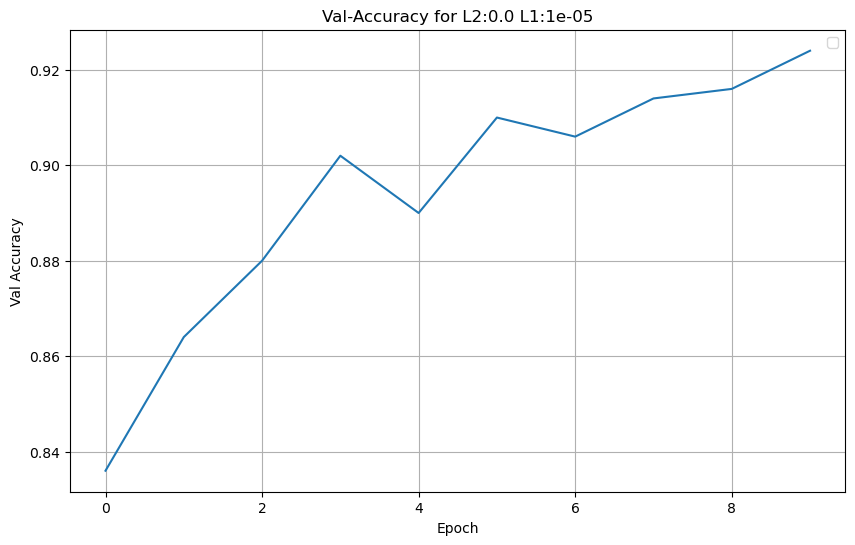

In [40]:

# Visualisierung der Validierungsgenauigkeit
plt.figure(figsize=(10,6))
plt.plot(history['val_acc'])
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.title('Val-Accuracy for L2:' + str(lambda_l2) + ' L1:' + str(lambda_l1))
plt.legend()
plt.grid(True)
plt.show()


In [41]:
import math

def plot_fc1_filters(model, name, n=16, cmap='coolwarm'):
    W = model.fc1.weight.detach().cpu()
    vmax = float(W.abs().max())
    k = int(math.sqrt(n))
    fig, axes = plt.subplots(k, k, figsize=(2*k, 2*k))
    for i, ax in enumerate(axes.flat[:n]):
        img = W[i].reshape(28, 28)
        im = ax.imshow(img, cmap=cmap, vmin=-vmax, vmax=vmax)
        ax.set_title(f'{i}', fontsize=8)
        ax.axis('off')
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
    plt.suptitle(f'fc1 Gewichte als 28×28 ( {name} )')
    plt.tight_layout()
    plt.show()

def plot_fc2_heatmap(model, name, cmap='coolwarm'):
    W = model.fc2.weight.detach().cpu()  # (10, hidden)
    vmax = float(W.abs().max())
    plt.figure(figsize=(8, 3))
    plt.imshow(W, aspect='auto', cmap=cmap, vmin=-vmax, vmax=vmax)
    plt.colorbar(shrink=0.7)
    plt.yticks(ticks=range(10), labels=[str(i) for i in range(10)])
    plt.xlabel('Hidden-Neuron')
    plt.ylabel('Klasse')
    plt.title(f'fc2 Gewichtsmatrix ( {name} )')
    plt.tight_layout()
    plt.show()

def plot_weight_hist(model, name, layer='fc1'):
    W = getattr(model, layer).weight.detach().cpu().view(-1)
    plt.figure(figsize=(6,3))
    plt.hist(W.numpy(), bins=60, color='steelblue', alpha=0.9)
    plt.title(f'Histogramm {layer}.weight ( {name} )')
    plt.xlabel('Gewicht')
    plt.ylabel('Häufigkeit')
    plt.tight_layout()
    plt.show()

def weight_stats(model):
    stats = {}
    for lname in ['fc1', 'fc2']:
        W = getattr(model, lname).weight.detach().cpu()
        stats[lname] = {
            'L1_norm': float(W.abs().sum()),
            'L2_norm': float(W.pow(2).sum().sqrt()),
            'max_abs': float(W.abs().max()),
            'sparsity_frac(|w|<1e-3)': float((W.abs() < 1e-3).float().mean())
        }
    return stats


C:\Users\johannes.schwab\AppData\Local\Temp\ipykernel_27964\1825896746.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


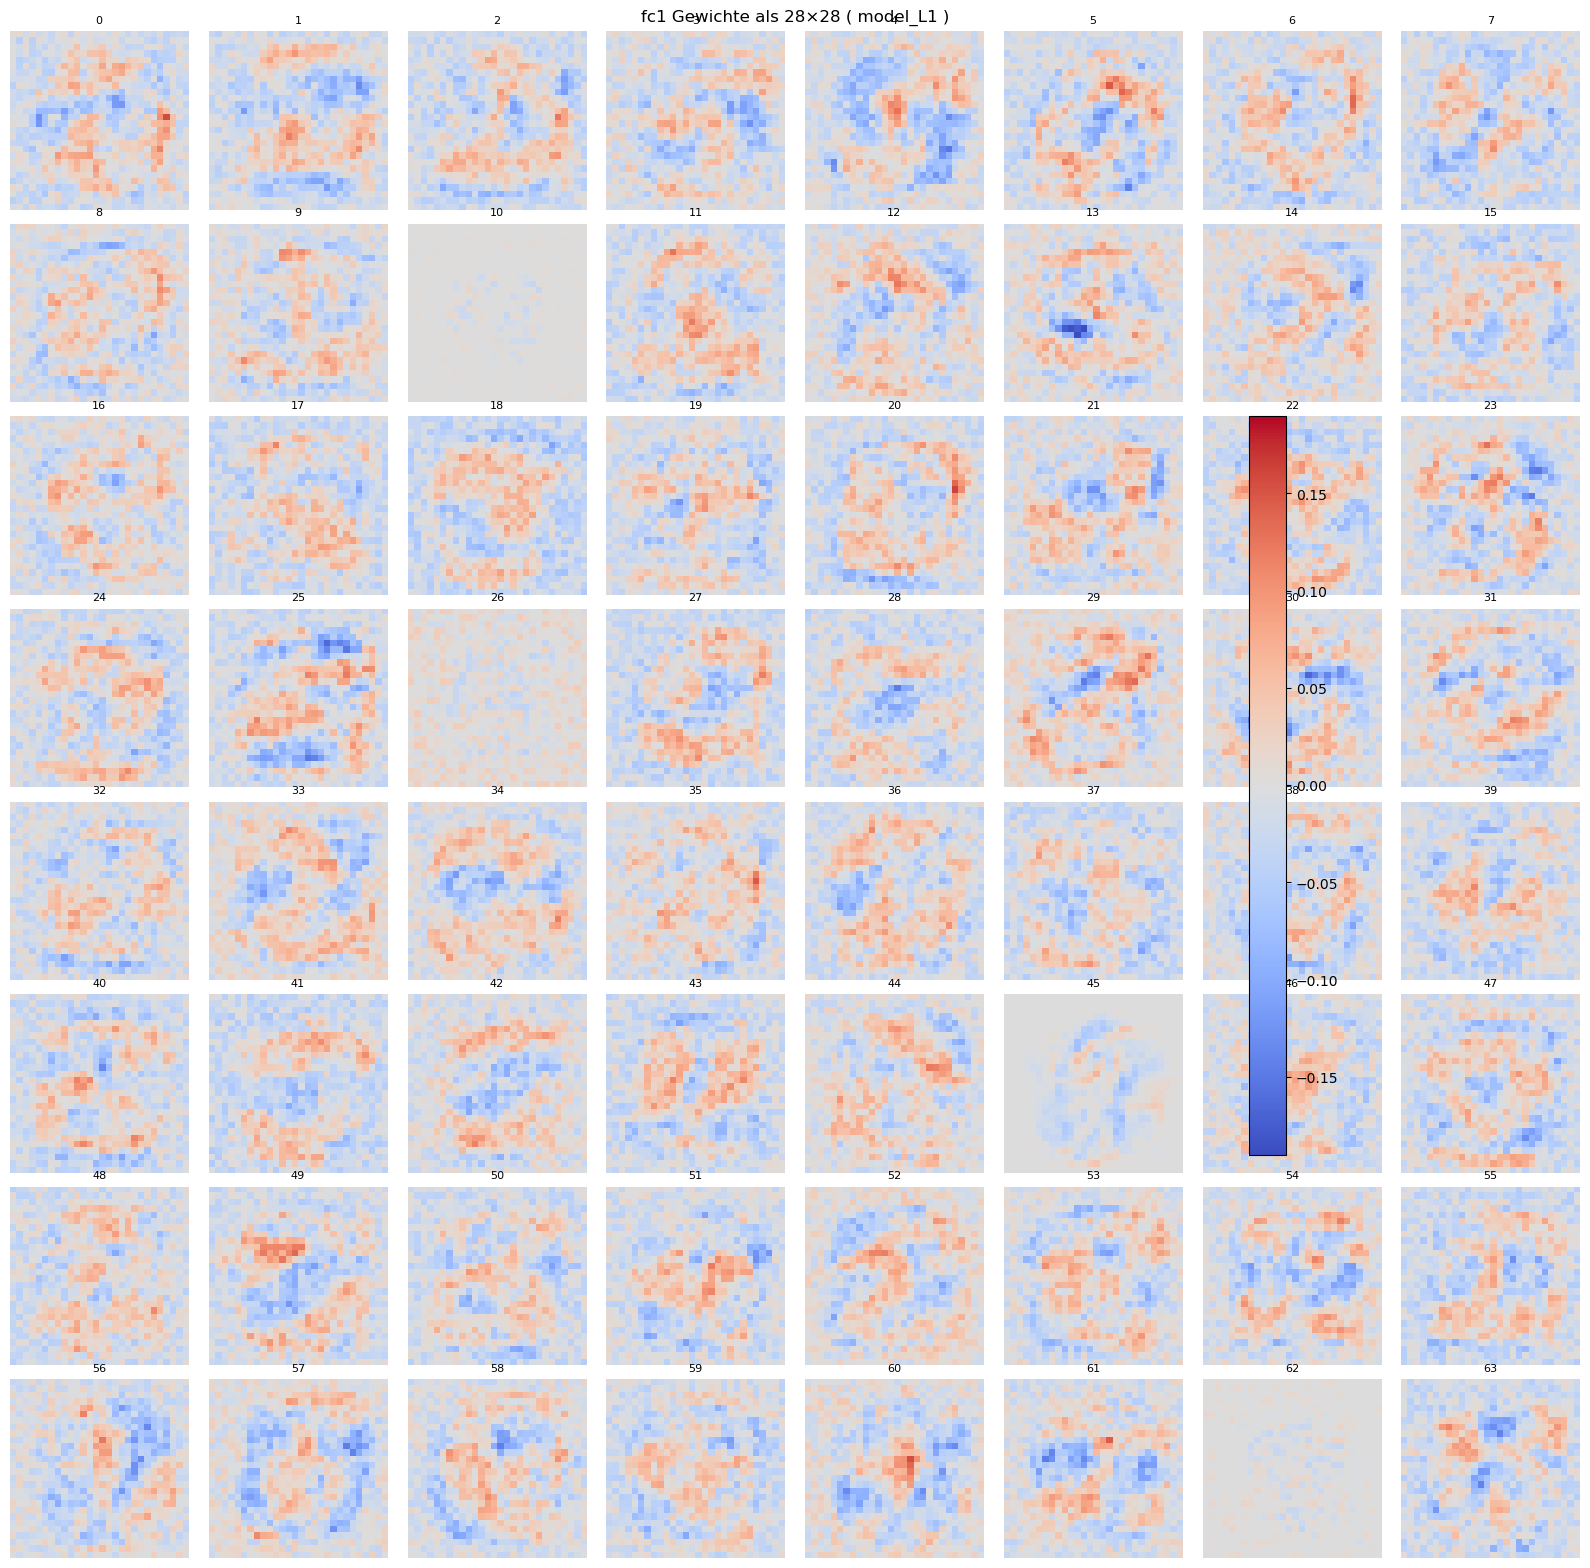

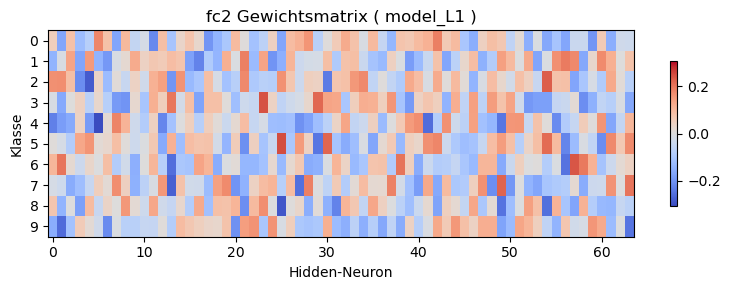

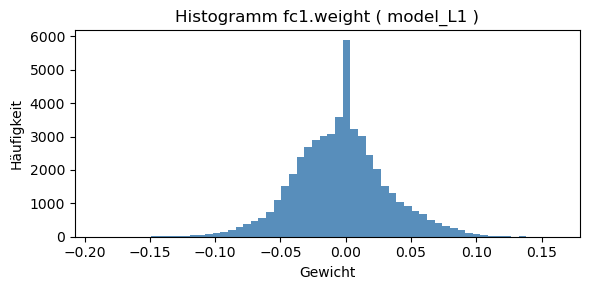

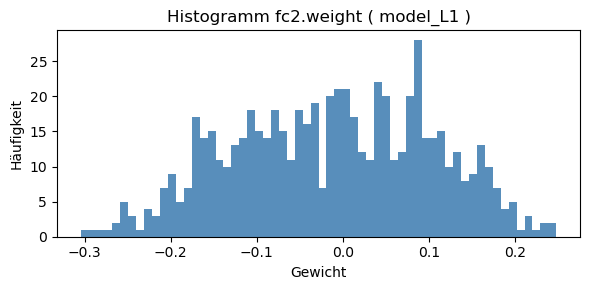

model_L1 {'fc1': {'L1_norm': 1347.13134765625, 'L2_norm': 7.960702896118164, 'max_abs': 0.18990206718444824, 'sparsity_frac(|w|<1e-3)': 0.06381537020206451}, 'fc2': {'L1_norm': 61.88838577270508, 'L2_norm': 2.9307198524475098, 'max_abs': 0.3044426739215851, 'sparsity_frac(|w|<1e-3)': 0.0078125}}


In [42]:

plot_fc1_filters(model, name, n=64)     # 
plot_fc2_heatmap(model, name)           # Heatmap der zweiten Schicht
plot_weight_hist(model, name, layer='fc1')
plot_weight_hist(model, name, layer='fc2')
print(name, weight_stats(model))

## Hinweise
- Du kannst die Experimente oben anpassen oder einzelne Konfigurationen auskommentieren.
- Die harten Constraints (nonneg, max_norm, clip) werden nach jedem Optimizer-Step projiziert.
- L1 wird als zusätzlicher Verlustterm nur auf Gewichte der expliziten Linearschichten angewandt.
- Early Stopping ist standardmäßig aktiv (patience=3).
